# 06 — Reconstruction accuracy

This notebook validates the three-mode DMD structure on individual wingbeat sequences. We run DMD on each valid sequence and examine the distribution of reconstruction errors: overall, per marker, per individual, and over horizontal distance. The plotting functions are reusable for both flapping-only and full-flight datasets.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget
%config InlineBackend.figure_format='svg'

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display
from morphing_birds import Animal3D
from scripts.plot_reconstruction import (
    MARKER_POSITIONS,
    add_bird_labels,
    plot_individual_histograms,
    plot_marker_histograms_per_frame,
    plot_overall_histogram,
    plot_rmse_distance_subsets,
)

from birddmd import batch_rmse_analysis, filter_sequences, remove_time_duplicates

## 1 — Load the full dataset for all individuals and distances

We load the complete flight dataset, which pools sequences from all five birds across multiple distances and recording sessions. Each sequence contains the morphing kinematics from flapping, gliding, landing recorded with motion capture.

In [ ]:
column_names = np.load("../data/samples/ColumnNames_obstacle.npz")
marker_column_names = column_names["marker_column_names"]
info_column_names = column_names["info_column_names"]

file = np.load("../data/samples/FlappingBilateralNoRot.npz", allow_pickle=True)
marker_df = pd.DataFrame(file["marker_data"], columns=marker_column_names)
info_df = pd.DataFrame(file["info_data"], columns=info_column_names)
flights_df = pd.concat([info_df, marker_df], axis=1)
flights_df = remove_time_duplicates(flights_df)

print(f"Loaded {flights_df.shape[0]} frames, {flights_df['seqID'].nunique()} sequences")

## 2 — Filter sequences

Not all recorded sequences are suitable for DMD. We apply three quality filters:

1. **Maximum gap** — no time gap between consecutive frames exceeds 0.15 s (rejects sequences with missing data).
2. **Start time** — the sequence begins within the first 0.15 s of the wingbeat cycle.
3. **Minimum length** — at least 30 frames after filtering (ensures enough data for a stable DMD fit).

In [3]:
valid_seqIDs = filter_sequences(
    flights_df,
    gap_threshold=0.15,
    time_start_max=0.15,
    min_frames=30,
)

print(f"Valid sequences: {len(valid_seqIDs)}")

Valid sequences: 413


## 3 — Batch DMD + RMSE analysis

This runs DMD on every valid sequence and collects per-sequence and
per-marker RMSE values.  This may take several minutes.

In [4]:
hawk3d = Animal3D("hawk", "../data/mean_hawk_shape.csv")
average_shape = hawk3d.markers
marker_names = hawk3d.analysis_marker_names

results_df = batch_rmse_analysis(
    df=flights_df,
    seqIDs=valid_seqIDs,
    marker_column_names=marker_column_names,
    average_shape=average_shape,
    n_modes=6,
    d=2,
    marker_names=marker_names,
    verbose=True,
    per_frame=True,
)

print(f"Successfully analysed {len(results_df)} sequences")
results_df.head()

/Users/lfrance/Library/CloudStorage/OneDrive-Personal/004 GitHub/BirdDMD/.venv/lib/python3.12/site-packages/pydmd/bopdmd.py:478: RuntimeWarning: overflow encountered in exp
  return np.exp(np.outer(t, alpha))


Could not solve variable projection. This failure is often the result of the real eigenvalues being too large and creating infs in the solution. Try reducing the rank or providing a constraint on the real eigenvalues.
Eigenvalues=[ 3.6863518e+03 -0.32793644j -7.4154705e-01+33.920227j
 -7.4154705e-01-33.920227j    3.6863518e+03 +0.32793644j
 -3.9754514e+03 +1.8058707j  -3.9754514e+03 -1.8058707j ]
Skipping 01_09_355: BOPDMD fit failed: SVD did not converge in Linear Least Squares
** On entry to DLASCL, parameter number  4 had an illegal value
** On entry to DLASCL, parameter number  4 had an illegal value


/Users/lfrance/Library/CloudStorage/OneDrive-Personal/004 GitHub/BirdDMD/.venv/lib/python3.12/site-packages/pydmd/bopdmd.py:478: RuntimeWarning: overflow encountered in exp
  return np.exp(np.outer(t, alpha))


Could not solve variable projection. This failure is often the result of the real eigenvalues being too large and creating infs in the solution. Try reducing the rank or providing a constraint on the real eigenvalues.
Eigenvalues=[ 3.3344258e+04+1.1031527e+05j -2.1389730e+00+3.0809097e+01j
 -2.1389730e+00-3.0809097e+01j  3.3344258e+04-1.1031527e+05j
 -1.9259685e+00-1.0766234e+00j -1.9259685e+00+1.0766234e+00j]
Skipping 02_09_055: BOPDMD fit failed: SVD did not converge in Linear Least Squares
** On entry to DLASCL, parameter number  4 had an illegal value
** On entry to DLASCL, parameter number  4 had an illegal value


/Users/lfrance/Library/CloudStorage/OneDrive-Personal/004 GitHub/BirdDMD/.venv/lib/python3.12/site-packages/pydmd/bopdmd.py:478: RuntimeWarning: overflow encountered in exp
  return np.exp(np.outer(t, alpha))


...

/Users/lfrance/Library/CloudStorage/OneDrive-Personal/004 GitHub/BirdDMD/.venv/lib/python3.12/site-packages/pydmd/bopdmd.py:478: RuntimeWarning: overflow encountered in exp
  return np.exp(np.outer(t, alpha))


Could not solve variable projection. This failure is often the result of the real eigenvalues being too large and creating infs in the solution. Try reducing the rank or providing a constraint on the real eigenvalues.
Eigenvalues=[ 5.4380238e+04-1.7546734e+05j  5.4380238e+04+1.7546734e+05j
 -7.2386193e-01+2.8028566e+01j -7.2386193e-01-2.8028566e+01j
  1.4959744e+00-1.8321231e-01j  1.4959744e+00+1.8321231e-01j]** On entry to DLASCL, parameter number  4 had an illegal value
** On entry to DLASCL, parameter number  4 had an illegal value

Skipping 04_09_075_2: BOPDMD fit failed: SVD did not converge in Linear Least Squares


/Users/lfrance/Library/CloudStorage/OneDrive-Personal/004 GitHub/BirdDMD/.venv/lib/python3.12/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 118340.0276247291. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(


Successfully analysed 406 sequences


,seqID,total_rmse,BirdID,Year,PerchDistance,Naive,Obstacle,Turn,IMU,rmse_left_wingtip,rmse_right_wingtip,rmse_left_primary,rmse_right_primary,rmse_left_secondary,rmse_right_secondary,rmse_left_tailtip,rmse_right_tailtip,rmse_per_frame,rmse_per_frame_per_marker,horz_distance
0,01_05_187,0.030901,1,2017,5,1,0,Straight,0,0.047200,0.046290,0.031610,0.032178,0.023158,0.021195,0.010223,0.011986,"[0.024576650683435456, 0.019209988939632723, 0...","[[0.03485384067975492, 0.01754760199214818, 0....","[4.36455696054454, 4.32275290947018, 4.2807091..."
1,01_05_193,0.023927,1,2017,5,1,0,Straight,0,0.036233,0.035501,0.021620,0.022650,0.019620,0.018545,0.010791,0.013455,"[0.025197731898746325, 0.051055030901291605, 0...","[[0.04024683848540203, 0.036355656960353824, 0...","[4.43925379969145, 4.40022253094592, 4.2811681..."
2,01_05_197,0.022941,1,2017,5,1,0,Straight,0,0.035663,0.035080,0.021905,0.022991,0.013643,0.014259,0.011715,0.013148,"[0.03495891986966622, 0.03320152268284499, 0.0...","[[0.052897226431346055, 0.06252483830709717, 0...","[4.15255288110781, 4.11686959509117, 4.0817581..."
3,01_05_199,0.023319,1,2017,5,1,0,Straight,0,0.035796,0.035013,0.023288,0.023226,0.014008,0.013752,0.011527,0.015586,"[0.07351606379823385, 0.03524123770788777, 0.0...","[[0.1193964368395017, 0.11861766701237442, 0.0...","[4.14558587395467, 4.03723430077556, 4.0014017..."
4,01_05_201,0.025450,1,2017,5,1,0,Straight,0,0.037887,0.038851,0.024569,0.025778,0.019157,0.019040,0.010877,0.010988,"[0.03291789447537483, 0.01685295585334295, 0.0...","[[0.064609174872236, 0.044020021796071375, 0.0...","[4.23405511659941, 4.19578784396435, 4.1579676..."


## 4 — Flapping flight results

Error distributions for the flapping-only dataset (413 individual wingbeat sequences across five birds, multiple distances, and recording sessions). Plotting functions are defined in `scripts/plot_reconstruction.py`.

### Mean RMSE per frame, pooling all markers and individuals

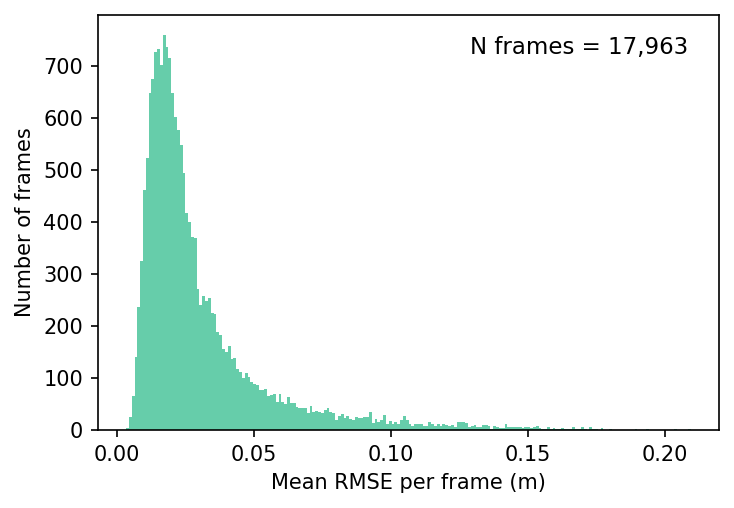

In [5]:
results_df = add_bird_labels(results_df)

fig = plot_overall_histogram(results_df, bins=200)
fig.savefig("figures/06_rmse_overall.svg", format="svg", bbox_inches="tight")
fig.savefig("figures/06_rmse_overall.png", format="png", dpi=150, bbox_inches="tight")
plt.close(fig)
display(Image("figures/06_rmse_overall.png"))

### RMSE per frame, separated by Marker

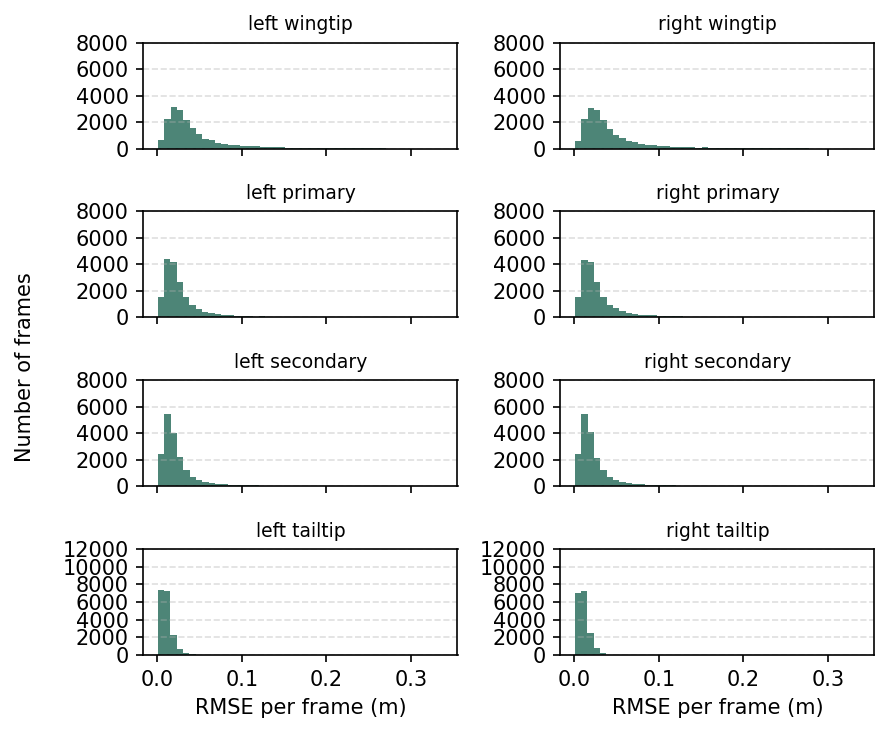

In [6]:
fig = plot_marker_histograms_per_frame(results_df, marker_names, bin_width=0.0075)
fig.savefig(
    "figures/06_rmse_per_marker_per_frame.svg", format="svg", bbox_inches="tight"
)
fig.savefig(
    "figures/06_rmse_per_marker_per_frame.png",
    format="png",
    dpi=150,
    bbox_inches="tight",
)
plt.close(fig)
display(Image("figures/06_rmse_per_marker_per_frame.png"))

### How many Frames have 0.2m RMSE Error Per Marker

In [7]:
threshold = 0.2
name_to_idx = {n: i for i, n in enumerate(marker_names)}

print(f"Frames with per-marker RMSE > {threshold} m:\n")
for pos in MARKER_POSITIONS:
    for side in ["left", "right"]:
        idx = name_to_idx[f"{side}_{pos}"]
        all_vals = np.concatenate(
            [arr[:, idx] for arr in results_df["rmse_per_frame_per_marker"].values]
        )
        n_above = int(np.sum(all_vals > threshold))
        pct = 100 * n_above / len(all_vals)
        print(f"  {side:>5} {pos:<10}  {n_above:>5} / {len(all_vals):>6}  ({pct:.2f}%)")

Frames with per-marker RMSE > 0.2 m:

   left wingtip       244 /  17963  (1.36%)
  right wingtip       255 /  17963  (1.42%)
   left primary        14 /  17963  (0.08%)
  right primary        18 /  17963  (0.10%)
   left secondary       0 /  17963  (0.00%)
  right secondary       0 /  17963  (0.00%)
   left tailtip         0 /  17963  (0.00%)
  right tailtip         0 /  17963  (0.00%)


### Mean RMSE per Frame across markers, separated by Individual

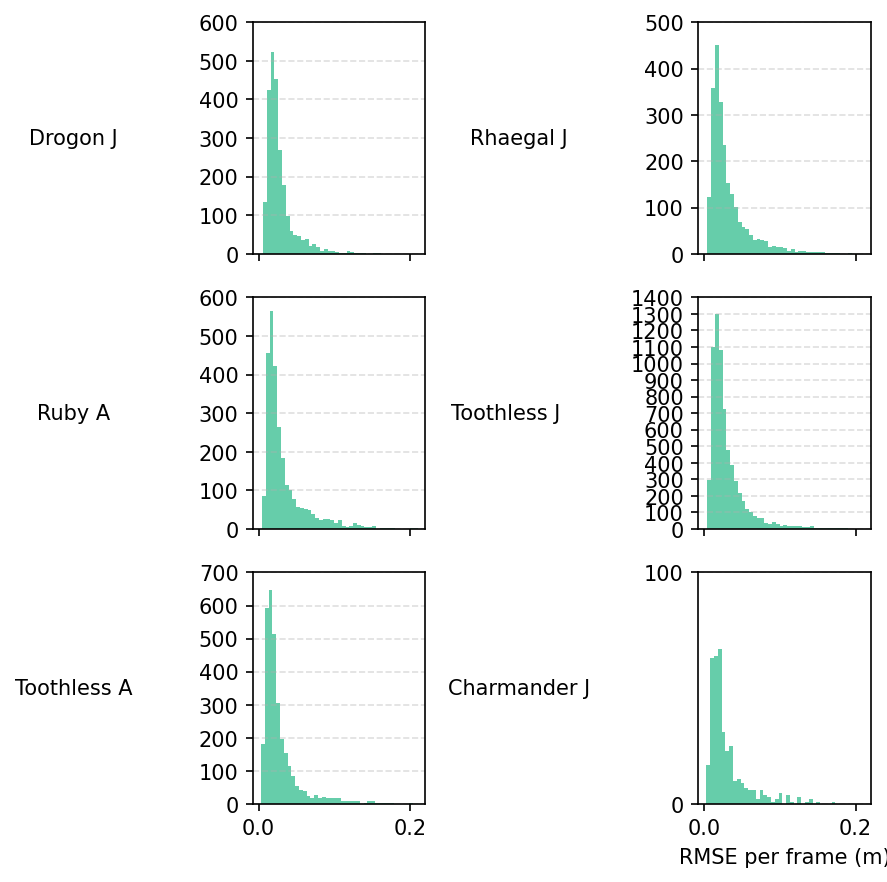

In [8]:
fig = plot_individual_histograms(results_df)
fig.savefig("figures/06_rmse_per_individual.svg", format="svg", bbox_inches="tight")
fig.savefig(
    "figures/06_rmse_per_individual.png", format="png", dpi=150, bbox_inches="tight"
)
plt.close(fig)
display(Image("figures/06_rmse_per_individual.png"))

In [9]:
print("Summary statistics (total RMSE per sequence):")
print(f"  Mean:   {results_df['total_rmse'].mean():.4f} m")
print(f"  Median: {results_df['total_rmse'].median():.4f} m")
print(f"  Std:    {results_df['total_rmse'].std():.4f} m")
rmse_min = results_df["total_rmse"].min()
rmse_max = results_df["total_rmse"].max()
print(f"  Range:  {rmse_min:.4f} - {rmse_max:.4f} m")

Summary statistics (total RMSE per sequence):
  Mean:   0.0400 m
  Median: 0.0396 m
  Std:    0.0089 m
  Range:  0.0183 - 0.0799 m


## 5 — RMSE over distance: 9 m subsets

Scatter + boxplot panels breaking down the 9 m flights by recording period and obstacle condition. This isolates the effect of each factor on reconstruction error across the approach.

In [ ]:
column_names = np.load("../data/samples/ColumnNames_obstacle.npz")
marker_column_names = column_names["marker_column_names"]
info_column_names = column_names["info_column_names"]

file = np.load("../data/samples/FullBilateralNoRot.npz", allow_pickle=True)
marker_df = pd.DataFrame(file["marker_data"], columns=marker_column_names)
info_df = pd.DataFrame(file["info_data"], columns=info_column_names)
flightsfull_df = pd.concat([info_df, marker_df], axis=1)
flightsfull_df = remove_time_duplicates(flightsfull_df)

n_frames = flightsfull_df.shape[0]
n_seqs = flightsfull_df["seqID"].nunique()
print(f"Loaded {n_frames} frames, {n_seqs} sequences")

In [11]:
valid_seqIDs = filter_sequences(
    flightsfull_df,
    gap_threshold=0.15,
    time_start_max=0.15,
    min_frames=30,
)

print(f"Valid sequences: {len(valid_seqIDs)}")

Valid sequences: 262


In [12]:
hawk3d = Animal3D("hawk", "../data/mean_hawk_shape.csv")
average_shape = hawk3d.markers
marker_names = hawk3d.analysis_marker_names

results_full_df = batch_rmse_analysis(
    df=flightsfull_df,
    seqIDs=valid_seqIDs,
    marker_column_names=marker_column_names,
    average_shape=average_shape,
    n_modes=6,
    d=2,
    marker_names=marker_names,
    verbose=True,
    per_frame=True,
)

print(f"Successfully analysed {len(results_full_df)} sequences")

/Users/lfrance/Library/CloudStorage/OneDrive-Personal/004 GitHub/BirdDMD/.venv/lib/python3.12/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 1812351.0095987509. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
/Users/lfrance/Library/CloudStorage/OneDrive-Personal/004 GitHub/BirdDMD/.venv/lib/python3.12/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 130269.99913880524. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
/Users/lfrance/Library/CloudStorage/OneDrive-Personal/004 GitHub/BirdDMD/.venv/lib/python3.12/site-packages/pydmd/bopdmd.py:478: RuntimeWarning: overflow encountered in exp
  return np.exp(np.outer(t, alpha))


Could not solve variable projection. This failure is often the result of the real eigenvalues being too large and creating infs in the solution. Try reducing the rank or providing a constraint on the real eigenvalues.
Eigenvalues=[ 3.5654352e+04+1.7076722e-04j  3.5654352e+04-1.7076722e-04j
 -1.9119687e+00+2.7670942e+01j -1.9119687e+00-2.7670942e+01j
  1.1502019e+00+1.1254039e+00j  1.1502019e+00-1.1254039e+00j]** On entry to DLASCL, parameter number  4 had an illegal value
** On entry to DLASCL, parameter number  4 had an illegal value

Skipping 01_09_035_2: BOPDMD fit failed: SVD did not converge in Linear Least Squares


/Users/lfrance/Library/CloudStorage/OneDrive-Personal/004 GitHub/BirdDMD/.venv/lib/python3.12/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 206066.11003776296. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
/Users/lfrance/Library/CloudStorage/OneDrive-Personal/004 GitHub/BirdDMD/.venv/lib/python3.12/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 104316.76024403147. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
/Users/lfrance/Library/CloudStorage/OneDrive-Personal/004 GitHub/BirdDMD/.venv/lib/python3.12/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 102213.38418626599. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
/Users/lfrance/Library/CloudStorage/OneDrive-Personal/004 GitHub/BirdDMD/.venv/lib/python3.12/site-pack

Could not solve variable projection. This failure is often the result of the real eigenvalues being too large and creating infs in the solution. Try reducing the rank or providing a constraint on the real eigenvalues.
Eigenvalues=[ 3.0955549e+03-6.0805592e-09j -6.9702244e-01+3.0052675e+01j
 -6.9702244e-01-3.0052675e+01j -2.4700113e-01+4.0128160e+00j
 -2.4700113e-01-4.0128160e+00j  3.0955549e+03+6.0805592e-09j]
Skipping 03_12_292: BOPDMD fit failed: SVD did not converge in Linear Least Squares
** On entry to DLASCL, parameter number  4 had an illegal value
** On entry to DLASCL, parameter number  4 had an illegal value


/Users/lfrance/Library/CloudStorage/OneDrive-Personal/004 GitHub/BirdDMD/.venv/lib/python3.12/site-packages/pydmd/bopdmd.py:478: RuntimeWarning: overflow encountered in exp
  return np.exp(np.outer(t, alpha))


...

/Users/lfrance/Library/CloudStorage/OneDrive-Personal/004 GitHub/BirdDMD/.venv/lib/python3.12/site-packages/pydmd/bopdmd.py:478: RuntimeWarning: overflow encountered in exp
  return np.exp(np.outer(t, alpha))


Could not solve variable projection. This failure is often the result of the real eigenvalues being too large and creating infs in the solution. Try reducing the rank or providing a constraint on the real eigenvalues.
Eigenvalues=[-1.1416922e+05-8.0746282e-03j -1.2364691e+00+2.8804104e+01j
 -1.2364691e+00-2.8804104e+01j  5.2166229e-01+1.4327316e+00j
  5.2166229e-01-1.4327316e+00j -1.1416922e+05+8.0746282e-03j]** On entry to DLASCL, parameter number  4 had an illegal value
** On entry to DLASCL, parameter number  4 had an illegal value

Skipping 04_09_072_2: BOPDMD fit failed: SVD did not converge in Linear Least Squares


/Users/lfrance/Library/CloudStorage/OneDrive-Personal/004 GitHub/BirdDMD/.venv/lib/python3.12/site-packages/pydmd/bopdmd.py:478: RuntimeWarning: overflow encountered in exp
  return np.exp(np.outer(t, alpha))
/Users/lfrance/Library/CloudStorage/OneDrive-Personal/004 GitHub/BirdDMD/.venv/lib/python3.12/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 130079.90306513038. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(


Could not solve variable projection. This failure is often the result of the real eigenvalues being too large and creating infs in the solution. Try reducing the rank or providing a constraint on the real eigenvalues.
Eigenvalues=[ 2.1239160e+04-6.1746570e+04j -1.8548138e+00+2.9568317e+01j
 -1.8548138e+00-2.9568317e+01j  2.1615912e-01+1.7081335e+00j
  2.1615912e-01-1.7081335e+00j  2.1239160e+04+6.1746570e+04j]** On entry to DLASCL, parameter number  4 had an illegal value
** On entry to DLASCL, parameter number  4 had an illegal value

Skipping 04_09_078_2: BOPDMD fit failed: SVD did not converge in Linear Least Squares
Successfully analysed 255 sequences


/Users/lfrance/Library/CloudStorage/OneDrive-Personal/004 GitHub/BirdDMD/.venv/lib/python3.12/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 413889.89185858885. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(


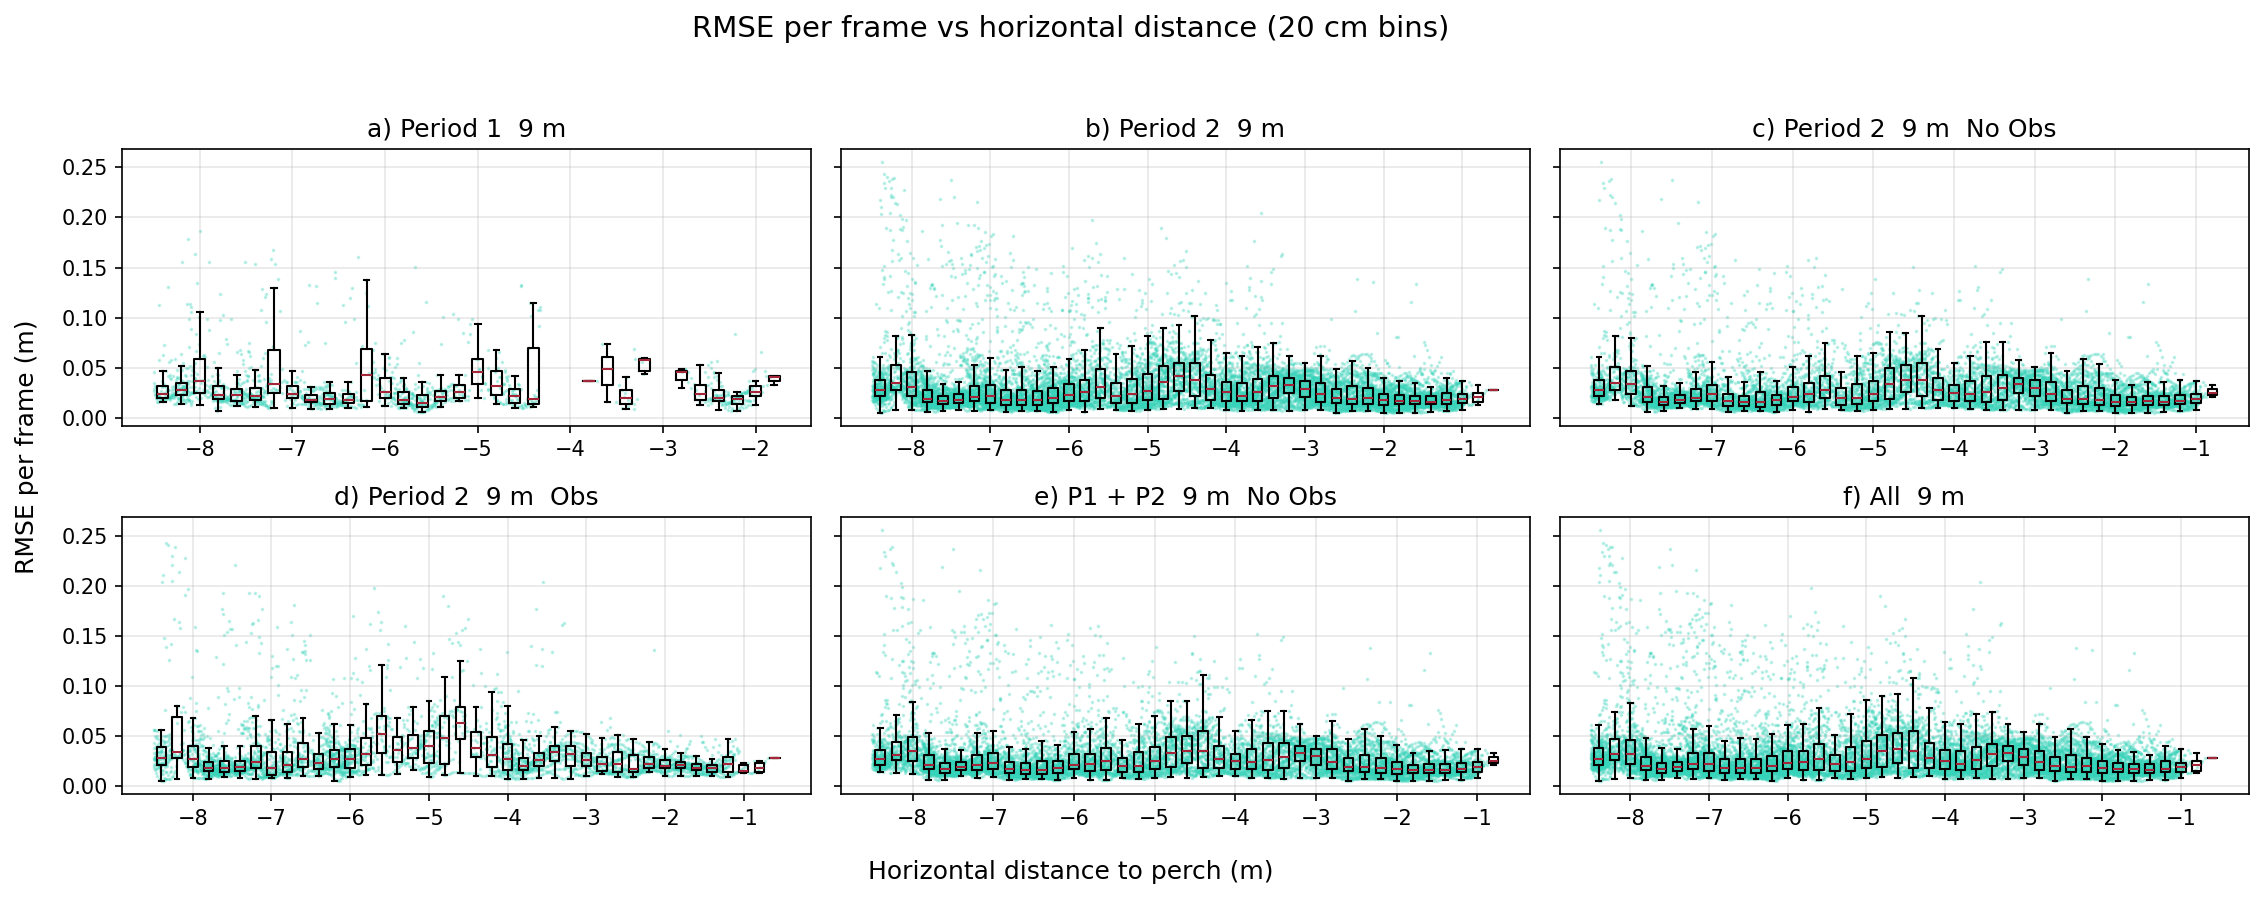

In [13]:
groups = [
    ("a) Period 1  9 m", {"Year": 2017, "PerchDistance": 9}),
    ("b) Period 2  9 m", {"Year": 2020, "PerchDistance": 9}),
    ("c) Period 2  9 m  No Obs", {"Year": 2020, "PerchDistance": 9, "Obstacle": 0}),
    ("d) Period 2  9 m  Obs", {"Year": 2020, "PerchDistance": 9, "Obstacle": 1}),
    ("e) P1 + P2  9 m  No Obs", {"PerchDistance": 9, "Obstacle": 0}),
    ("f) All  9 m", {"PerchDistance": 9}),
]

fig = plot_rmse_distance_subsets(results_full_df, groups, bin_width=0.2)
fig.savefig(
    "figures/06_rmse_per_frame_vs_distance.svg", format="svg", bbox_inches="tight"
)
fig.savefig(
    "figures/06_rmse_per_frame_vs_distance.png",
    format="png",
    dpi=150,
    bbox_inches="tight",
)
plt.close(fig)
display(Image("figures/06_rmse_per_frame_vs_distance.png"))

## Next

The final notebook (`07_generative_model`) demonstrates how the fitted DMD model can be used generatively: stabilised forecasting, frequency modification, and synthetic flight generation.